# Farmer: Conditional Value at Risk

Use the same [20 synthetic harvests](Farmer_SAA.ipynb) to examine the price of protecting bad outcomes. First inspect a fixed plan's profit distribution, then optimize the planting decision. All distributions below are finite empirical distributions with equal weights.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 7 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
import sys
from pathlib import Path
if "google.colab" in sys.modules:
    from urllib.request import urlretrieve
    base = "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/"
    for name in ["helper.py", "farmer.py"]:
        urlretrieve(base + name, name)
    import helper
    helper.easy_install()
else:
    sys.path.insert(0, str(Path.cwd().parent))
    import helper
import farmer as f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
helper.set_plotting_style()


In [2]:
def show_solution(record):
    display(pd.Series(record["acreage"], name="Planted acres").to_frame().round(3))
    rows = []
    for s in record["scenarios"]:
        row = {"Scenario": s["id"], "Probability": s["probability"]}
        row.update({"Buy " + c + " (T)": v for c, v in s["purchases_tons"].items()})
        row.update({"Sell " + c + " (T)": v for c, v in s["sales_tons"].items()})
        row["Profit ($)"] = s["profit"]
        rows.append(row)
    display(pd.DataFrame(rows).set_index("Scenario").round(2))
    print(f"Expected profit: ${record['expected_profit']:,.2f}")


## Loss, quantile, and tail average

Write loss as $L=-P$. At confidence level $\alpha$, VaR is the smallest threshold with cumulative probability at least $\alpha$. CVaR averages the worst probability mass $1-\alpha$, including only the required fraction of an atom at the cutoff.

For 20 equal weights and $\alpha=0.8$, that tail is the four worst outcomes. A loss can be negative: positive profit corresponds to negative loss. We display the equivalent lower-tail profit $C^-_\alpha(P)=-\operatorname{CVaR}_\alpha(-P)$, so larger is better.

In [3]:
neutral = f.solve_farmer(f.build_farmer(f.TWENTY))
neutral_record = f.evaluate_solution(f.plan_of(neutral), f.TWENTY)
profits = np.array([s["profit"] for s in neutral_record["scenarios"]])
order = np.argsort(profits)
display(pd.DataFrame({"Scenario": order+1, "Profit ($)": profits[order]}).round(2))
print("Mean profit:", profits.mean())
print("Lower-tail profit at alpha=0.8:", f.lower_tail_profit(profits, .8))


,Scenario,Profit ($)
0,6,13987.03
1,11,17231.07
2,1,37505.39
3,17,71715.18
4,5,76578.81
5,19,80946.78
6,18,81533.99
7,12,83099.85
8,16,84633.08
9,14,96869.63


Mean profit: 103193.43152366493
Lower-tail profit at alpha=0.8: 35109.66974272152


## The optimization problem and Pyomo

Retain the farmer land, feed, beet-quota, and nonnegativity constraints. Add
$$\min_{\mathbf{x},\mathbf{y},\eta,\mathbf z}
\eta+\frac{1}{1-\alpha}\sum_s p_s z_s,
\qquad z_s\ge -P_s-\eta,\quad z_s\ge0.$$
This is an **epigraph** formulation: auxiliary variables bound the positive-part losses from above. In profit notation, $\nu=-\eta$ gives the equivalent maximization below. The crop balances and shared acreage are unchanged.

In [4]:
def attach_tail_objective(m, alpha):
    """Maximize the lower-tail profit: equivalent to minimizing CVaR of loss."""
    if not 0 <= alpha < 1:
        raise ValueError("Use 0 <= alpha < 1")
    m.nu = f.pyo.Var(units=f.u.USD)
    m.z = f.pyo.Var(m.SCENARIOS, domain=f.pyo.NonNegativeReals, units=f.u.USD)
    m.tail_shortfall = f.pyo.Constraint(
        m.SCENARIOS, rule=lambda m, s: m.z[s] >= m.nu - m.scenarios[s].profit)
    m.objective.deactivate()
    m.tail_objective = f.pyo.Objective(
        expr=m.nu-sum(m.weight[s]*m.z[s] for s in m.SCENARIOS)/(1-alpha),
        sense=f.pyo.maximize)


In [5]:
policies = []
for alpha in [0, .5, .8, .9, .95]:
    m = f.build_farmer(f.TWENTY)
    attach_tail_objective(m, alpha)
    f.solve_farmer(m)
    record = f.evaluate_solution(f.plan_of(m), f.TWENTY)
    p = np.array([s["profit"] for s in record["scenarios"]])
    np.testing.assert_allclose(p, f.analytic_profits(f.plan_of(m), f.TWENTY), atol=1e-6)
    np.testing.assert_allclose(f.pyo.value(m.tail_objective),
                               f.lower_tail_profit(p, alpha), atol=1e-6)
    policies.append({"alpha": alpha, "solution": record,
                     "optimized_tail": f.lower_tail_profit(p, alpha),
                     "common_tail80": f.lower_tail_profit(p,.8), "worst": float(p.min())})
display(pd.DataFrame([{"alpha": r["alpha"], **r["solution"]["acreage"],
    "Mean profit": r["solution"]["expected_profit"], "Tail at own alpha": r["optimized_tail"],
    "Tail at fixed alpha=.8": r["common_tail80"], "Worst": r["worst"]}
    for r in policies]).round(2))


,alpha,WHEAT,CORN,BEETS,Mean profit,Tail at own alpha,Tail at fixed alpha=.8,Worst
0,0.00,139.11,87.64,273.25,103193.43,103193.43,35109.67,13987.03
1,0.50,88.93,83.16,327.90,97893.83,69659.42,38108.76,13942.53
2,0.80,106.26,47.41,346.32,91519.31,38734.57,38734.57,16102.67
3,0.90,106.26,0.00,393.74,72435.57,17185.59,34152.85,16983.63
4,0.95,106.26,0.00,393.74,72435.57,16983.63,34152.85,16983.63


## Complete solution for a representative risk-averse policy

The alpha = 0.8 plan protects the worst four outcomes in this scenario model. Compare its land allocation and every recourse quantity with the risk-neutral solution. No claim is made that this is the right risk preference for every farmer.

In [6]:
show_solution(policies[2]["solution"])


,Planted acres
WHEAT,106.260
CORN,47.415
BEETS,346.325


,Probability,Buy WHEAT (T),Buy CORN (T),Sell WHEAT (T),Sell CORN (T),Sell BEETS_FAVORABLE (T),Sell BEETS_UNFAVORABLE (T),Profit ($)
Scenario,,,,,,,,
1,0.05,7.25,130.63,0.00,0.0,5232.52,0.00,42323.94
2,0.05,0.00,59.16,151.12,0.0,6000.00,3281.31,145190.42
3,0.05,0.00,73.32,76.45,0.0,6000.00,1604.69,112756.87
4,0.05,0.00,79.04,114.32,0.0,6000.00,1768.47,119632.38
5,0.05,0.00,115.14,34.78,0.0,6000.00,67.11,81515.76
6,0.05,-0.00,144.48,0.00,0.0,4537.04,0.00,16102.67
7,0.05,0.00,88.38,85.79,0.0,6000.00,1470.67,109842.15
8,0.05,0.00,97.28,96.55,0.0,6000.00,1639.01,111487.06
9,0.05,0.00,46.63,152.54,0.0,6000.00,2895.09,144201.69


Expected profit: $91,519.31


In [7]:
results = {"neutral": neutral_record, "policies": policies,
           "inputs20": [s["yield"] for s in f.TWENTY]}
helper.save_results("farmer-cvar-twenty", results,
    notebook="notebooks/4-dev/Farmer_CVaR.ipynb", source_tag="handout:farmer-tail-objective",
    solver="appsi_highs", description="Complete recourse and CVaR policies for 20 synthetic harvests",
    source_files=["notebooks/farmer.py"],
    source_cells=[("notebooks/4-dev/Farmer_CVaR.ipynb", "provenance:farmer-cvar-policy-study")])


[helper] wrote figures/results/farmer-cvar-twenty.json


[helper] wrote media/figures/farmer-cvar-twenty.png and .pdf


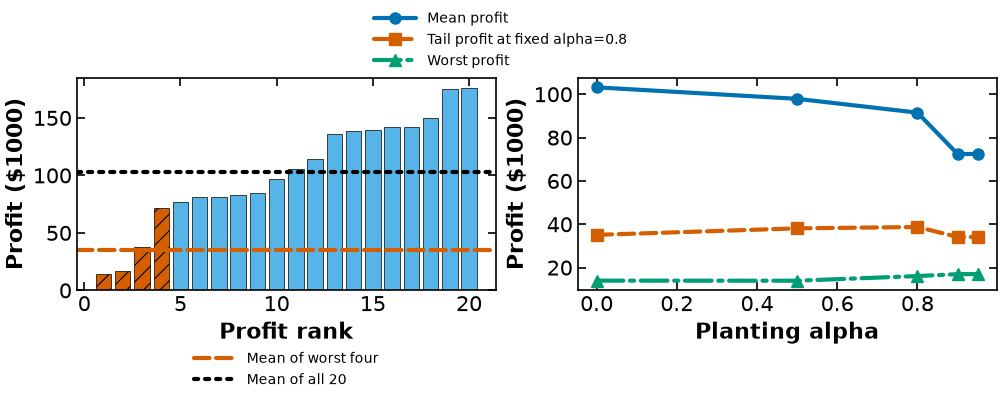

In [8]:
p = np.array([s["profit"] for s in results["neutral"]["scenarios"]])
order = np.argsort(p)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for j, i in enumerate(order):
    axes[0].bar(j+1, p[i]/1000, color="#D55E00" if j<4 else "#56B4E9",
                hatch="//" if j<4 else "", edgecolor="black", linewidth=.5)
axes[0].axhline(p[order[:4]].mean()/1000, color="#D55E00", ls="--",
               label="Mean of worst four")
axes[0].axhline(p.mean()/1000, color="black", ls=":", label="Mean of all 20")
axes[0].set(xlabel="Profit rank", ylabel="Profit ($1000)")
rows=results["policies"]; alpha=[r["alpha"] for r in rows]
for key, label, color, marker in [("mean", "Mean profit", "#0072B2", "o"),
    ("common_tail80", "Tail profit at fixed alpha=0.8", "#D55E00", "s"),
    ("worst", "Worst profit", "#009E73", "^")]:
    vals=[r["solution"]["expected_profit"] if key=="mean" else r[key] for r in rows]
    axes[1].plot(alpha, np.array(vals)/1000, color=color, marker=marker, label=label)
axes[1].set(xlabel="Planting alpha", ylabel="Profit ($1000)")
fig.legend(*axes[1].get_legend_handles_labels(), loc="outside upper center", ncol=1, fontsize=10)
axes[0].legend(loc="upper center", bbox_to_anchor=(.5,-.23), fontsize=10)
helper.save_figure(fig, "farmer-cvar-twenty")


## Endpoints and implementation detail

At alpha = 0, the entire distribution is in the tail, so the objective is expected profit. With 20 equal weights, alpha at least 0.95 and below 1 selects only the worst outcome. This is a worst-case criterion for the **retained scenarios**, not every possible harvest. Do not substitute alpha = 1 into the formula.

The optimized threshold need not be unique, especially at discrete quantiles. Calculate reported CVaR from the resulting distribution, including partial atom mass, rather than treating an arbitrary solver threshold as a unique statistical estimate.

A pure tail objective need not reward efficient trades in a good scenario. We therefore fix optimized acreage and maximize profit separately in every scenario before reporting the policy's outcomes. This improves recourse without altering planting decisions. The independent piecewise recourse formula checks every reported profit.

For a mean/tail blend, maximize $(1-\lambda)\mathbb E[P]+\lambda C^-_\alpha(P)$ at fixed alpha. Alpha selects tail probability; lambda weights the two criteria. Comparing policies using a common fixed-alpha metric avoids confusing a changed definition of the tail with a changed planting decision.

**Primary sources:** Rockafellar & Uryasev (2000), *Optimization of Conditional Value-at-Risk*, [DOI](https://doi.org/10.21314/JOR.2000.038); Rockafellar & Uryasev (2002), *Conditional value-at-risk for general loss distributions*, Definitions 1 and 3, Proposition 8, Theorem 10 and Corollary 12, [DOI](https://doi.org/10.1016/S0378-4266(02)00271-6).

## Balance mean profit and the same tail

At a fixed $\alpha=0.8$, maximize $(1-\lambda)\mathbb E[P]+\lambda C^-_{0.8}(P)$ for $0\le\lambda\le1$. Here $\lambda$ changes the importance of the unfavorable tail while its definition stays fixed. The table reports **separately reoptimized recourse** for each chosen acreage and evaluates every policy on the same 20 harvests. Compare the endpoints and explain the acreage shift; values between them need not change smoothly.


In [9]:
blend_rows = []
for weight in [0, .25, .5, .75, 1.0]:
    blend = f.solve_farmer(f.build_farmer(f.TWENTY, risk={"cvar": (.8, weight)}))
    solved = f.evaluate_solution(f.plan_of(blend), f.TWENTY)
    profits = np.array([s["profit"] for s in solved["scenarios"]])
    np.testing.assert_allclose(profits, f.analytic_profits(f.plan_of(blend), f.TWENTY), atol=1e-6)
    blend_rows.append({"Mean weight": 1-weight, "Tail weight": weight,
        **solved["acreage"], "Mean profit ($)": solved["expected_profit"],
        "CVaR profit at alpha=.8 ($)": f.lower_tail_profit(profits, .8),
        "Worst profit ($)": profits.min()})
display(pd.DataFrame(blend_rows).round(2))


,Mean weight,Tail weight,WHEAT,CORN,BEETS,Mean profit ($),CVaR profit at alpha=.8 ($),Worst profit ($)
0,1.00,0.00,139.11,87.64,273.25,103193.43,35109.67,13987.03
1,0.75,0.25,133.83,89.97,276.20,103155.74,35614.76,14163.60
2,0.50,0.50,110.26,89.59,300.16,101589.01,37875.65,15152.67
3,0.25,0.75,106.26,89.59,304.15,101192.76,38060.62,15319.10
4,0.00,1.00,106.26,47.41,346.32,91519.31,38734.57,16102.67


## How planting and production change with alpha

At alpha = 0, optimizing CVaR is expected-value optimization. At alpha = 0.95, the tail contains one of the 20 equally weighted scenarios, so the objective mitigates the worst case **within this sample**.

The top row shows planted acreage. The bottom row shows mean crop production and the full range across the same 20 harvests. Production means harvest before purchases or sales. Shading is a scenario range, not a confidence interval. Solutions are computed on a grid of alpha values; connecting lines guide the eye and do not imply a smoothly changing optimizer.

In [10]:
alpha_sweep = []
yields20 = np.array([[s["yield"][c] for c in f.CROPS] for s in f.TWENTY])
for alpha in np.linspace(0, .95, 20):
    m = f.build_farmer(f.TWENTY)
    attach_tail_objective(m, float(alpha))
    f.solve_farmer(m)
    acreage = f.plan_of(m)
    production = yields20 * acreage
    profits = f.analytic_profits(acreage, f.TWENTY)
    np.testing.assert_allclose(f.pyo.value(m.tail_objective),
                               f.lower_tail_profit(profits, alpha), atol=1e-6)
    alpha_sweep.append({"alpha": float(alpha), "acreage": acreage.tolist(),
        "production_mean": production.mean(axis=0).tolist(),
        "production_min": production.min(axis=0).tolist(),
        "production_max": production.max(axis=0).tolist(),
        "tail_profit": f.lower_tail_profit(profits, alpha)})
results = {"sweep": alpha_sweep, "yields20": yields20.tolist(),
           "crops": f.CROPS, "seed": f.SYNTHETIC_SEED}
helper.save_results("farmer-alpha-acreage-production", results,
    notebook="notebooks/4-dev/Farmer_CVaR.ipynb", source_tag="handout:farmer-tail-objective",
    solver="appsi_highs", description="Acreage and harvest production versus alpha; 20 equal-weight scenarios",
    source_files=["notebooks/farmer.py"],
    source_cells=[("notebooks/4-dev/Farmer_CVaR.ipynb", "provenance:farmer-alpha-sweep")])


[helper] wrote figures/results/farmer-alpha-acreage-production.json


[helper] wrote media/figures/farmer-alpha-acreage-production.png and .pdf


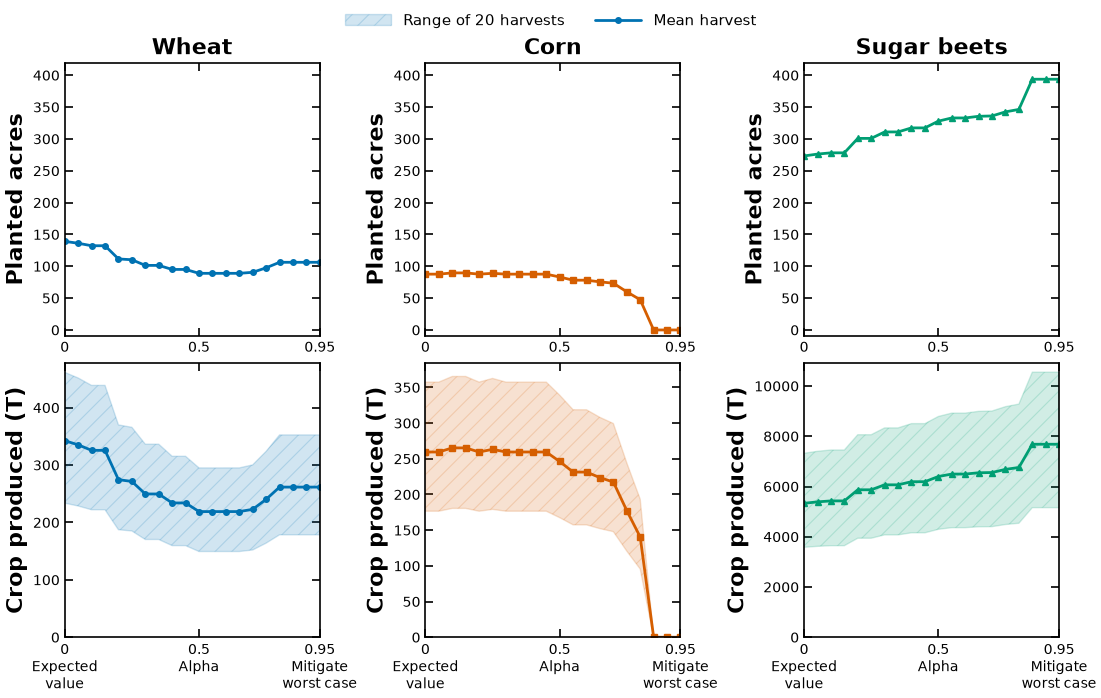

In [11]:
rows = results["sweep"]
a = np.array([r["alpha"] for r in rows])
fig, axes = plt.subplots(2, 3, figsize=(11, 7), layout="constrained")
for j, (crop, color, marker) in enumerate(zip(
    ["Wheat", "Corn", "Sugar beets"], ["#0072B2", "#D55E00", "#009E73"], ["o", "s", "^"])):
    planted = np.array([r["acreage"][j] for r in rows])
    mean = np.array([r["production_mean"][j] for r in rows])
    low = np.array([r["production_min"][j] for r in rows])
    high = np.array([r["production_max"][j] for r in rows])
    axes[0,j].plot(a, planted, color=color, marker=marker, ms=4, linewidth=2)
    axes[0,j].set(title=crop, ylabel="Planted acres", ylim=(-10, 420))
    axes[1,j].fill_between(a, low, high, color=color, alpha=.18, hatch="//",
                           label="Range of 20 harvests")
    axes[1,j].plot(a, mean, color=color, marker=marker, ms=4, linewidth=2,
                   label="Mean harvest")
    axes[1,j].set(ylabel="Crop produced (T)")
    axes[1,j].set_ylim(bottom=0)
    for ax in axes[:,j]:
        ax.set_xlim(0,.95)
        ax.tick_params(labelsize=10)
    axes[0,j].set_xticks([0,.5,.95], labels=["0", "0.5", "0.95"])
    axes[1,j].set_xticks([0,.5,.95], labels=["0\nExpected\nvalue", "0.5\nAlpha", "0.95\nMitigate\nworst case"])
fig.legend(*axes[1,0].get_legend_handles_labels(), loc="outside upper center", ncol=2, fontsize=11)
helper.save_figure(fig, "farmer-alpha-acreage-production")
